`const_vdv_rich.tsv`

In [3]:
import requests
from pathlib import Path

vdv_consts_name = "const_vdv_rich.tsv"
vdv_consts_path = Path(f"/drive/data/{vdv_consts_name}")
vdv_consts_path.write_text(
    requests.get(
        f"https://cdn.lazarev.fun/data/{vdv_consts_name}"
    ).content.decode("utf8")
)

import pandas as pd

vdv_consts = pd.read_csv(vdv_consts_path, sep="\t")
vdv_consts.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,cid,elements,atoms,bonds,...,cactvs_fingerprint,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,Азот,N2,0.137,38.7,28.014,2.998428,947,"['N', 'N']","[{'aid': 1, 'number': 7, 'element': 'N', 'x': ...","[{'aid1': 1, 'aid2': 2, 'order': 3}]",...,0000000000000011000000000000000000000000000000...,2,0,0,0,0,0,0,0,1


In [6]:
vdv_consts_numbers = vdv_consts.select_dtypes(include="number")
vdv_consts_numbers.head(1)

,Const_a,Const_b,Mol_weight,Volume,cid,charge,molecular_weight,exact_mass,monoisotopic_mass,tpsa,...,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,0.137,38.7,28.014,2.998428,947,0,28.014,28.006148,28.006148,47.6,...,0,2,0,0,0,0,0,0,0,1


In [7]:
y = vdv_consts["Mol_weight"]
X = vdv_consts_numbers.drop(columns=["Mol_weight"])

In [9]:
X.head(1)

,Const_a,Const_b,Volume,cid,charge,molecular_weight,exact_mass,monoisotopic_mass,tpsa,complexity,...,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,0.137,38.7,2.998428,947,0,28.014,28.006148,28.006148,47.6,8.0,...,0,2,0,0,0,0,0,0,0,1


In [13]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)
reg.score(X, y)

1.0

In [15]:
import numpy as np

np.argmax(reg.coef_)

np.int32(14)

In [20]:
X.columns[np.argmax(np.abs(reg.coef_))]

'isotope_atom_count'

<Axes: >

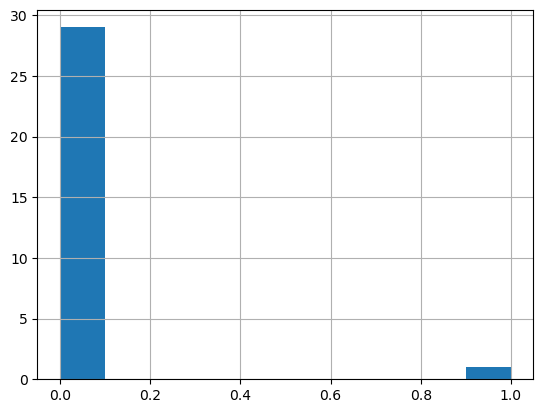

In [24]:
X.isotope_atom_count.hist()

In [22]:
print(*reg.coef_, sep="\n")

-4.691413906218835e-13
6.723788192886104e-15
1.6862623493721363e-14
3.8163916471489756e-16
2.541022947610827e-14
1.0000000000000466
9.510621457042845e-15
-5.705939193356713e-14
4.234649740239571e-15
7.57418216687511e-15
5.5642453196543505e-14
-8.33186296377627e-14
1.6366578976952616e-14
-1.3504239501811732e-14
2.883410000001017
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [25]:
list(zip(np.abs(reg.coef_), X.columns))

[(np.float64(4.691413906218835e-13), 'Const_a'),
 (np.float64(6.723788192886104e-15), 'Const_b'),
 (np.float64(1.6862623493721363e-14), 'Volume'),
 (np.float64(3.8163916471489756e-16), 'cid'),
 (np.float64(2.541022947610827e-14), 'charge'),
 (np.float64(1.0000000000000466), 'molecular_weight'),
 (np.float64(9.510621457042845e-15), 'exact_mass'),
 (np.float64(5.705939193356713e-14), 'monoisotopic_mass'),
 (np.float64(4.234649740239571e-15), 'tpsa'),
 (np.float64(7.57418216687511e-15), 'complexity'),
 (np.float64(5.5642453196543505e-14), 'h_bond_donor_count'),
 (np.float64(8.33186296377627e-14), 'h_bond_acceptor_count'),
 (np.float64(1.6366578976952616e-14), 'rotatable_bond_count'),
 (np.float64(1.3504239501811732e-14), 'heavy_atom_count'),
 (np.float64(2.883410000001017), 'isotope_atom_count'),
 (np.float64(0.0), 'atom_stereo_count'),
 (np.float64(0.0), 'defined_atom_stereo_count'),
 (np.float64(0.0), 'undefined_atom_stereo_count'),
 (np.float64(0.0), 'bond_stereo_count'),
 (np.float64(

In [27]:
sorted(list(zip(np.abs(reg.coef_), X.columns)), reverse=True)

[(np.float64(2.883410000001017), 'isotope_atom_count'),
 (np.float64(1.0000000000000466), 'molecular_weight'),
 (np.float64(4.691413906218835e-13), 'Const_a'),
 (np.float64(8.33186296377627e-14), 'h_bond_acceptor_count'),
 (np.float64(5.705939193356713e-14), 'monoisotopic_mass'),
 (np.float64(5.5642453196543505e-14), 'h_bond_donor_count'),
 (np.float64(2.541022947610827e-14), 'charge'),
 (np.float64(1.6862623493721363e-14), 'Volume'),
 (np.float64(1.6366578976952616e-14), 'rotatable_bond_count'),
 (np.float64(1.3504239501811732e-14), 'heavy_atom_count'),
 (np.float64(9.510621457042845e-15), 'exact_mass'),
 (np.float64(7.57418216687511e-15), 'complexity'),
 (np.float64(6.723788192886104e-15), 'Const_b'),
 (np.float64(4.234649740239571e-15), 'tpsa'),
 (np.float64(3.8163916471489756e-16), 'cid'),
 (np.float64(0.0), 'undefined_bond_stereo_count'),
 (np.float64(0.0), 'undefined_atom_stereo_count'),
 (np.float64(0.0), 'defined_bond_stereo_count'),
 (np.float64(0.0), 'defined_atom_stereo_coun

In [34]:
y = vdv_consts["Mol_weight"]
X = vdv_consts_numbers.drop(
    columns=[
        "Mol_weight", 
        "molecular_weight", 
        "exact_mass", 
        "monoisotopic_mass"
    ]
)

reg = LinearRegression()
reg.fit(X, y)
reg.score(X, y)

0.9552390590714636

In [35]:
sorted(list(zip(np.abs(reg.coef_), X.columns)), reverse=True)

[(np.float64(10.032626874538558), 'Volume'),
 (np.float64(6.8979182147052365), 'h_bond_acceptor_count'),
 (np.float64(6.285812532749274), 'isotope_atom_count'),
 (np.float64(2.3772165086684174), 'Const_a'),
 (np.float64(1.6268845632193925), 'rotatable_bond_count'),
 (np.float64(1.4993795072329685), 'heavy_atom_count'),
 (np.float64(0.5704795780180236), 'h_bond_donor_count'),
 (np.float64(0.22255347430437541), 'tpsa'),
 (np.float64(0.2188298289703556), 'complexity'),
 (np.float64(0.010794246240283155), 'Const_b'),
 (np.float64(0.000469760483404566), 'cid'),
 (np.float64(1.6431300764452317e-14), 'charge'),
 (np.float64(0.0), 'undefined_bond_stereo_count'),
 (np.float64(0.0), 'undefined_atom_stereo_count'),
 (np.float64(0.0), 'defined_bond_stereo_count'),
 (np.float64(0.0), 'defined_atom_stereo_count'),
 (np.float64(0.0), 'covalent_unit_count'),
 (np.float64(0.0), 'bond_stereo_count'),
 (np.float64(0.0), 'atom_stereo_count')]

In [36]:
y = vdv_consts["Const_b"]
X = vdv_consts_numbers.drop(
    columns=["Const_b", "Const_a"]
)

reg = LinearRegression()
reg.fit(X, y)
reg.score(X, y)

0.7393855597541964

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=len(X.columns))
pca.fit(vdv_consts_numbers)
print(*pca.explained_variance_ratio_, sep="\n")

0.9999708624064215
2.5334676924692256e-05
1.9661348152363157e-06
1.3307062285690238e-06
4.972454257066936e-07
4.24133315646468e-09
1.559258924925299e-09
1.4032830315175799e-09
7.184415300846891e-10
4.089331285754282e-10
2.717539675277209e-10
1.256876991996346e-10
7.571832728814314e-11
2.5774508644255375e-11
4.3477119820856605e-35
5.233078963634813e-39
0.0
0.0
0.0
0.0
0.0


In [42]:
print(*pca.components_[0], sep="\n")

-5.320345951568886e-07
-0.000422078434940909
0.001086496331097482
6.94120814739756e-05
0.9999976017565573
-0.0
0.0010602567755675918
0.0010624500769897752
0.001058155814175371
-0.00023988076395604777
-5.0796252333387346e-05
-9.228126033932382e-06
-1.0235962934327747e-05
-5.940377172021657e-07
-1.9666393662395865e-06
9.100181913041921e-06
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0


In [43]:
vdv_consts_numbers.head()

,Const_a,Const_b,Mol_weight,Volume,cid,charge,molecular_weight,exact_mass,monoisotopic_mass,tpsa,...,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,0.1370,38.7,28.014,2.998428,947,0,28.014,28.006148,28.006148,47.6,...,0,2,0,0,0,0,0,0,0,1
1,0.4225,37.1,17.031,1.873579,222,0,17.031,17.026549,17.026549,1.0,...,0,1,0,0,0,0,0,0,0,1
2,0.1355,32.0,39.900,4.988916,23968,0,39.900,39.962383,39.962383,0.0,...,0,1,0,0,0,0,0,0,0,1
3,0.4516,52.2,26.040,3.001687,6326,0,26.040,26.015650,26.015650,0.0,...,0,2,0,0,0,0,0,0,0,1
4,0.9750,59.1,159.810,14.476459,24408,0,159.810,159.834630,157.836680,0.0,...,0,2,0,0,0,0,0,0,0,1


In [45]:
%pip install seaborn

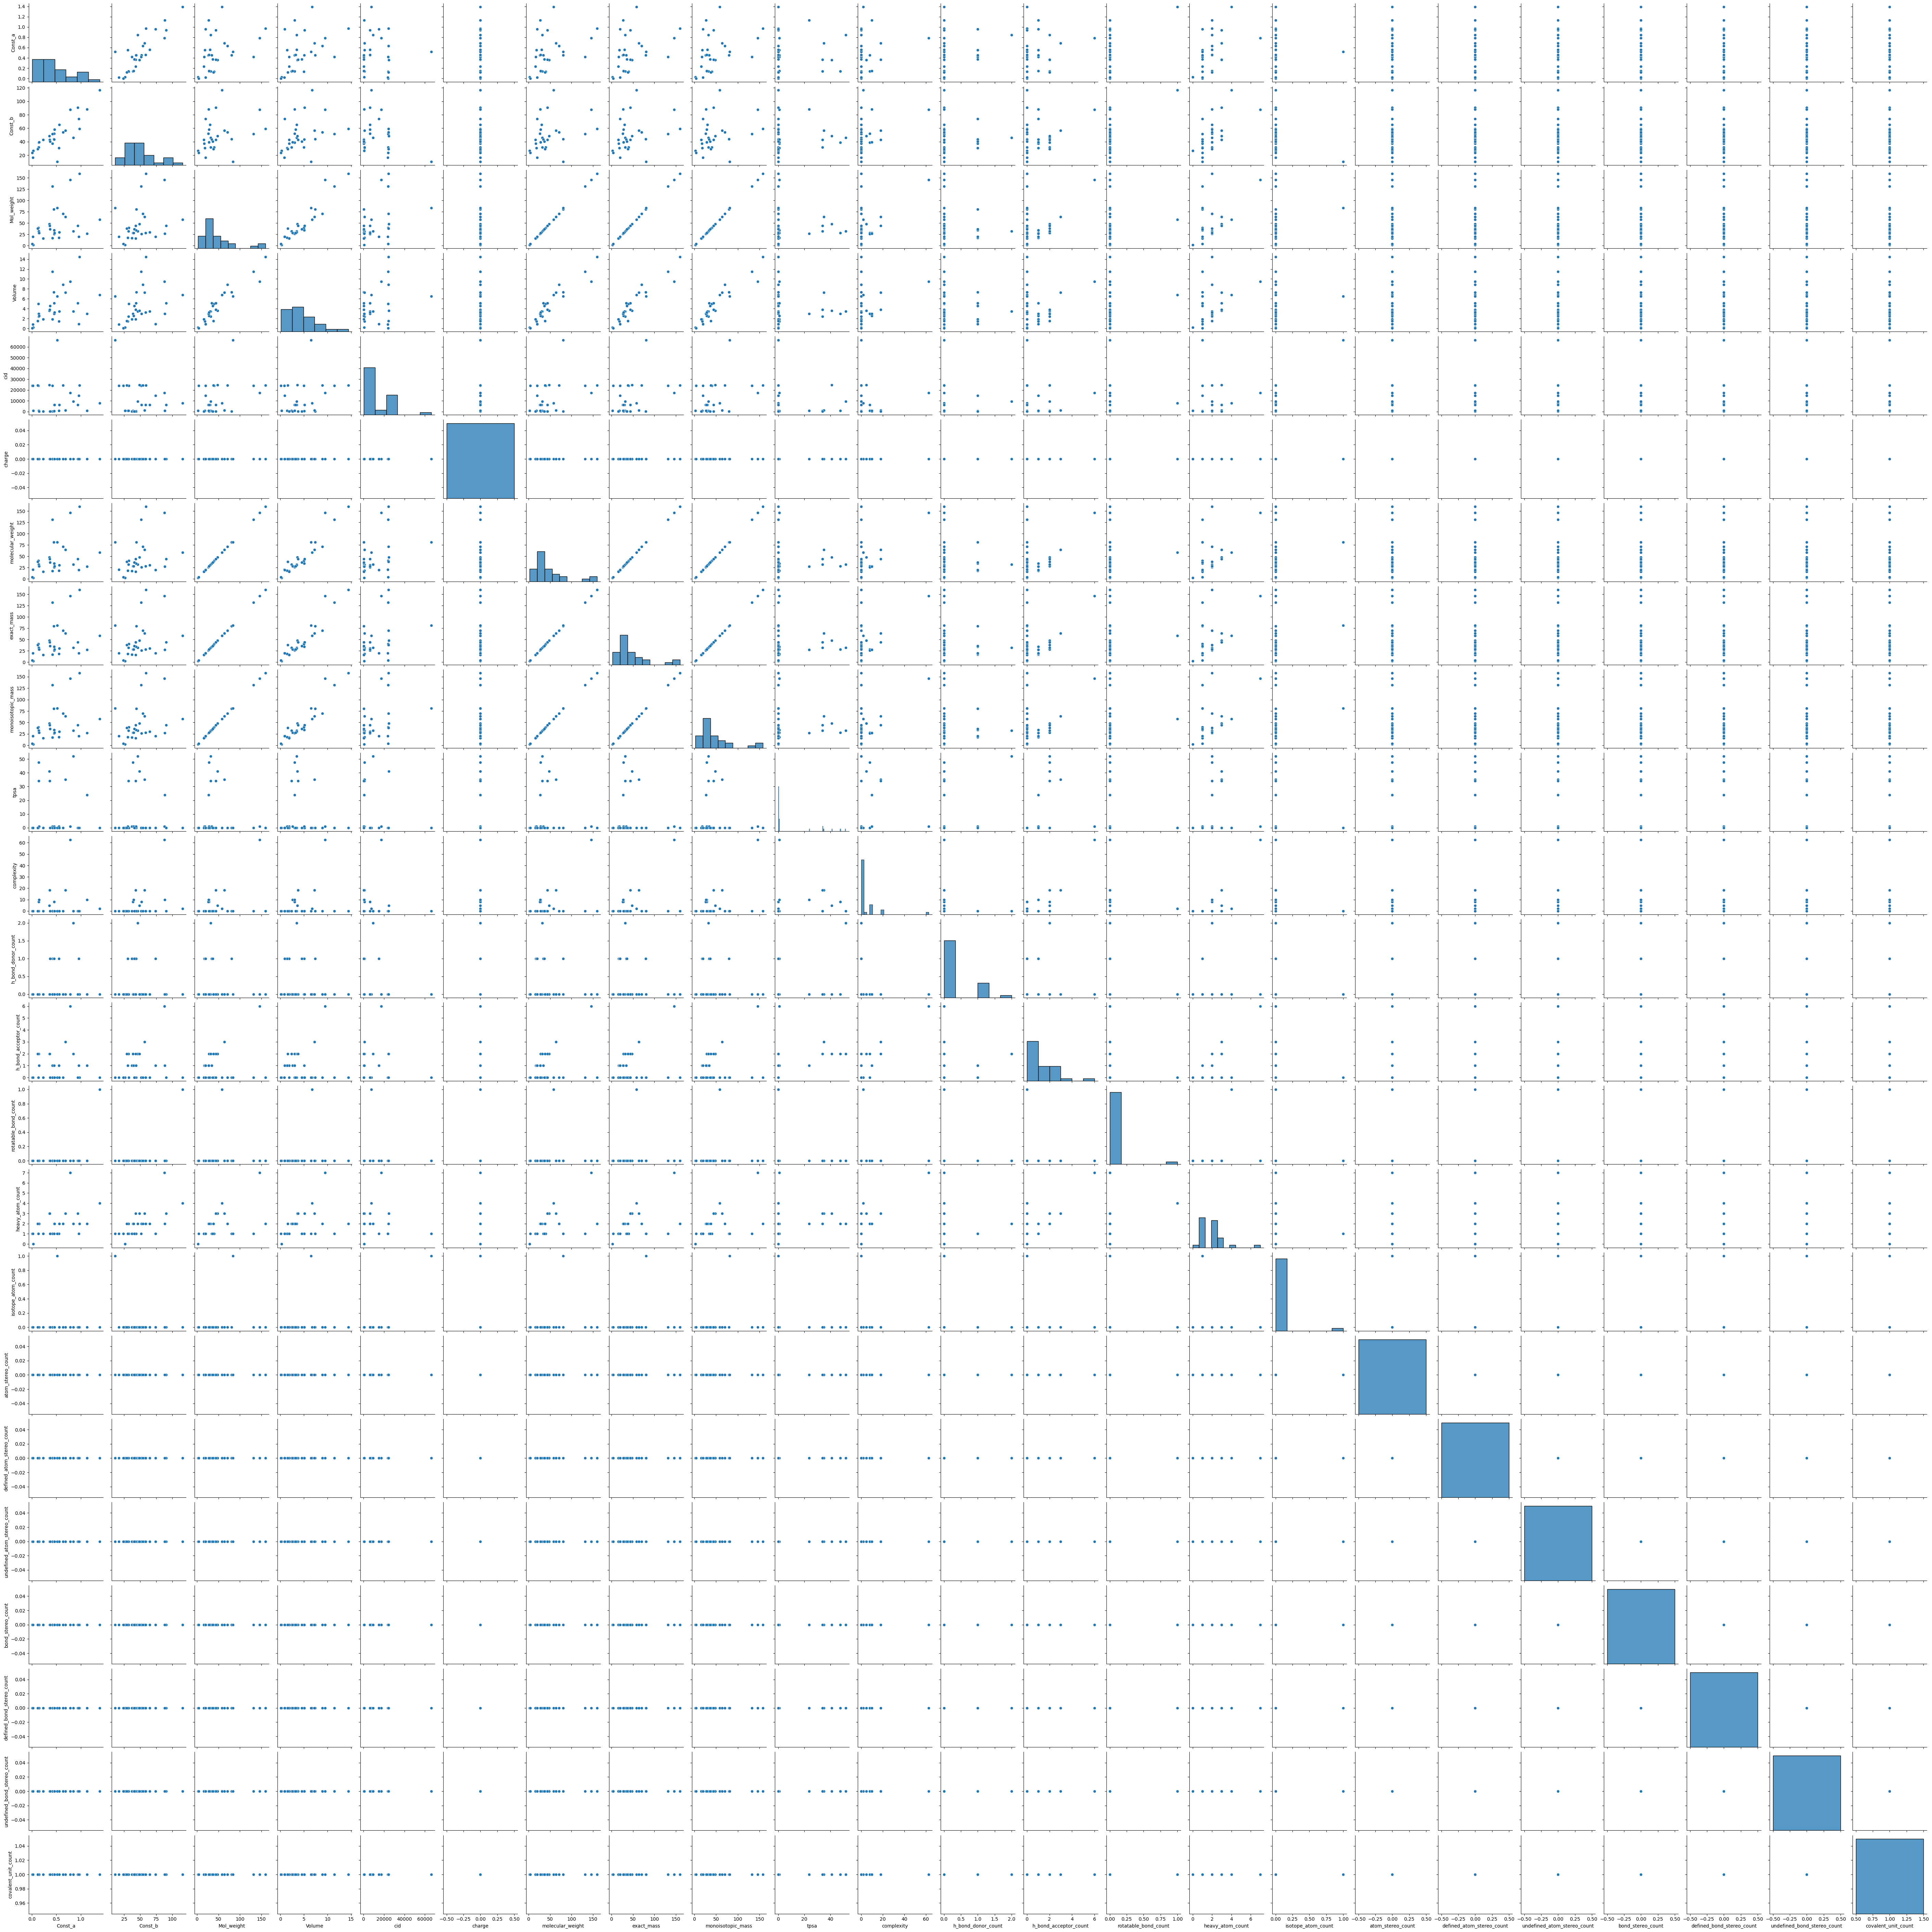

In [46]:
import seaborn as sns

sns.pairplot(vdv_consts_numbers)

In [47]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()
vdv_consts_numbers_transformed = \
    scaler.fit_transform(vdv_consts_numbers)
pca.fit(vdv_consts_numbers_transformed)
print(*pca.explained_variance_ratio_, sep="\n")

0.410885349140227
0.18689499846506033
0.13484961650919325
0.08532529788735975
0.07410063735173698
0.04662078620352463
0.029612372906487987
0.01688948576096712
0.005573583988628425
0.004336686843788043
0.0027752726284186414
0.0021321845087277553
2.8676143963480475e-06
8.601914837014826e-07
2.4080766911564728e-33
6.7767419161030805e-34
0.0
0.0
0.0
0.0
0.0
